In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configurações visuais
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'

# Carregando a tabela tratada
df = pd.read_csv('../outputs/olist_tratado.csv', parse_dates=['order_purchase_timestamp'])

print(f"Dados carregados: {df.shape[0]:,} linhas")
print(df[['customer_state', 'valor_total', 'dias_entrega', 'atrasou', 'review_score']].head())

Dados carregados: 110,189 linhas
  customer_state  valor_total  dias_entrega  atrasou  review_score
0             SP        38.71             8    False           4.0
1             BA       141.46            13    False           4.0
2             GO       179.12             9    False           5.0
3             RN        72.20            13    False           5.0
4             SP        28.62             2    False           5.0


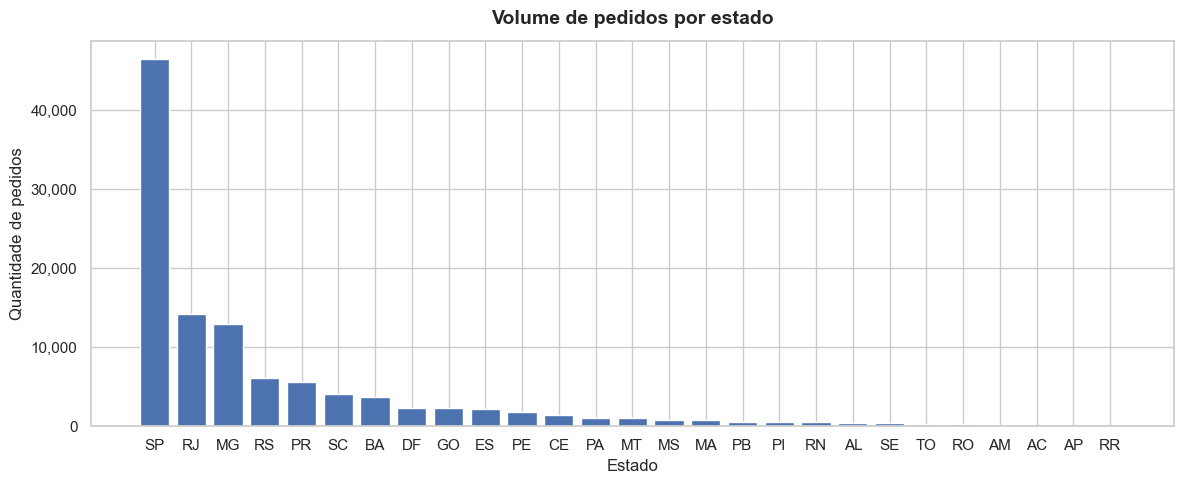

Top 3 estados:
  SP: 46,441 pedidos (42.1%)
  RJ: 14,143 pedidos (12.8%)
  MG: 12,916 pedidos (11.7%)


In [3]:
# Gráfico 1 — Volume de pedidos por estado
pedidos_estado = df.groupby('customer_state')['order_id'].count().sort_values(ascending=False)

fig, ax = plt.subplots()
bars = ax.bar(pedidos_estado.index, pedidos_estado.values, color='#4C72B0')
ax.set_title('Volume de pedidos por estado', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Estado')
ax.set_ylabel('Quantidade de pedidos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../outputs/01_pedidos_por_estado.png', dpi=150)
plt.show()

# Insight
top3 = pedidos_estado.head(3)
print("Top 3 estados:")
for estado, qtd in top3.items():
    print(f"  {estado}: {qtd:,} pedidos ({qtd/len(df)*100:.1f}%)")

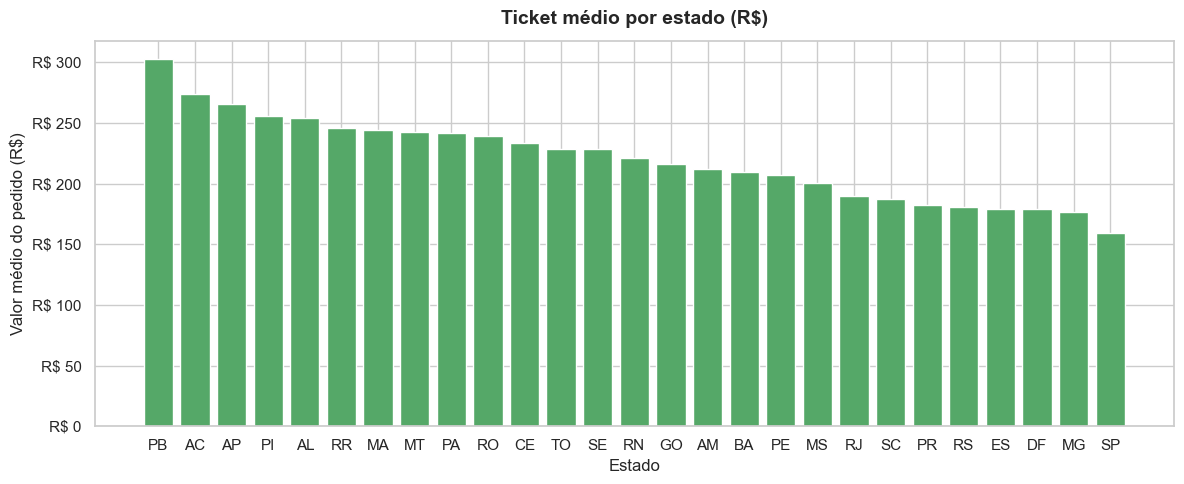

Top 3 maior ticket médio:
  PB: R$ 302.68
  AC: R$ 273.52
  AP: R$ 265.70

Top 3 menor ticket médio:
  DF: R$ 178.93
  MG: R$ 176.62
  SP: R$ 159.41


In [4]:
# Gráfico 2 — Ticket médio por estado
ticket_estado = df.groupby('customer_state')['valor_total'].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
bars = ax.bar(ticket_estado.index, ticket_estado.values, color='#55A868')
ax.set_title('Ticket médio por estado (R$)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Estado')
ax.set_ylabel('Valor médio do pedido (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

plt.tight_layout()
plt.savefig('../outputs/02_ticket_medio_estado.png', dpi=150)
plt.show()

# Insight
print("Top 3 maior ticket médio:")
for estado, valor in ticket_estado.head(3).items():
    print(f"  {estado}: R$ {valor:.2f}")

print("\nTop 3 menor ticket médio:")
for estado, valor in ticket_estado.tail(3).items():
    print(f"  {estado}: R$ {valor:.2f}")

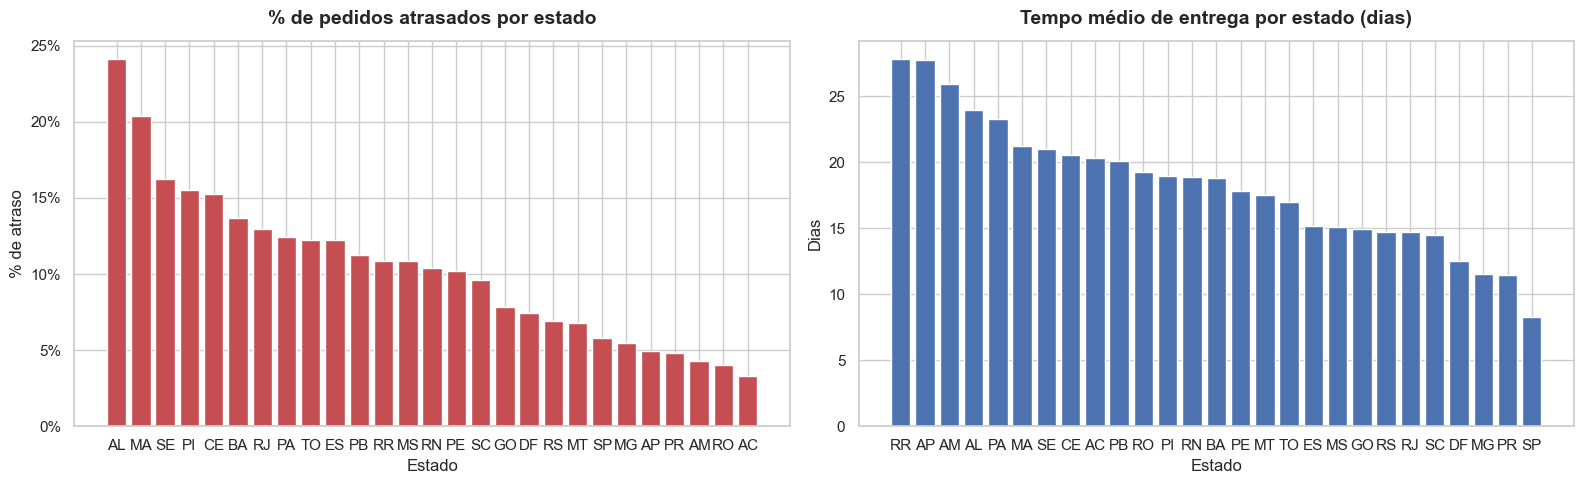

Top 5 estados com mais atraso:
  AL: 24.1% de atraso | 24.0 dias médios
  MA: 20.4% de atraso | 21.2 dias médios
  SE: 16.3% de atraso | 21.0 dias médios
  PI: 15.5% de atraso | 18.9 dias médios
  CE: 15.3% de atraso | 20.5 dias médios


In [5]:
# Gráfico 3 — % de atraso por estado
atraso_estado = df.groupby('customer_state').agg(
    pct_atraso=('atrasou', 'mean'),
    dias_medio=('dias_entrega', 'mean')
).sort_values('pct_atraso', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# % de atraso
axes[0].bar(atraso_estado['customer_state'], atraso_estado['pct_atraso'] * 100, color='#C44E52')
axes[0].set_title('% de pedidos atrasados por estado', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Estado')
axes[0].set_ylabel('% de atraso')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Dias médios de entrega
atraso_estado2 = atraso_estado.sort_values('dias_medio', ascending=False)
axes[1].bar(atraso_estado2['customer_state'], atraso_estado2['dias_medio'], color='#4C72B0')
axes[1].set_title('Tempo médio de entrega por estado (dias)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Estado')
axes[1].set_ylabel('Dias')

plt.tight_layout()
plt.savefig('../outputs/03_atraso_entrega_estado.png', dpi=150)
plt.show()

print("Top 5 estados com mais atraso:")
for _, row in atraso_estado.head(5).iterrows():
    print(f"  {row['customer_state']}: {row['pct_atraso']*100:.1f}% de atraso | {row['dias_medio']:.1f} dias médios")

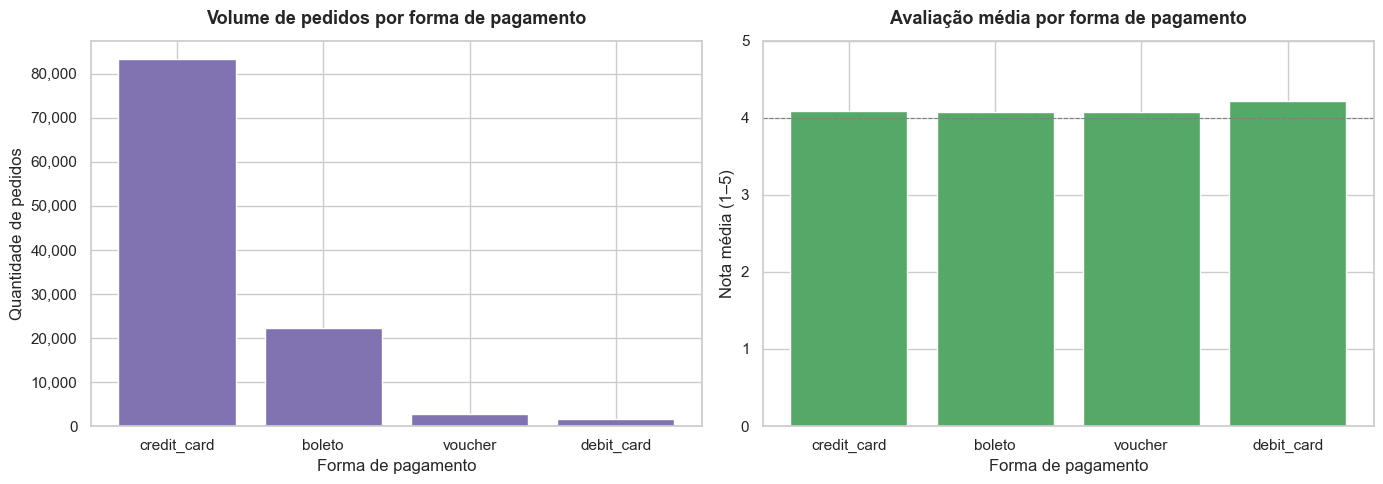

Resumo por forma de pagamento:
  credit_card: 83,344 pedidos | nota 4.08 | ticket R$ 182.50
  boleto: 22,362 pedidos | nota 4.07 | ticket R$ 176.33
  voucher: 2,829 pedidos | nota 4.07 | ticket R$ 132.49
  debit_card: 1,651 pedidos | nota 4.21 | ticket R$ 149.20


In [6]:
# Gráfico 4 — Volume e avaliação por forma de pagamento
pagamento = df.groupby('forma_pagamento').agg(
    qtd_pedidos=('order_id', 'count'),
    avaliacao_media=('review_score', 'mean'),
    ticket_medio=('valor_total', 'mean')
).sort_values('qtd_pedidos', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume por forma de pagamento
axes[0].bar(pagamento['forma_pagamento'], pagamento['qtd_pedidos'], color='#8172B2')
axes[0].set_title('Volume de pedidos por forma de pagamento', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Forma de pagamento')
axes[0].set_ylabel('Quantidade de pedidos')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Avaliação média por forma de pagamento
cores = ['#55A868' if v >= 4 else '#C44E52' for v in pagamento['avaliacao_media']]
axes[1].bar(pagamento['forma_pagamento'], pagamento['avaliacao_media'], color=cores)
axes[1].set_title('Avaliação média por forma de pagamento', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Forma de pagamento')
axes[1].set_ylabel('Nota média (1–5)')
axes[1].set_ylim(0, 5)
axes[1].axhline(y=4, color='gray', linestyle='--', linewidth=0.8, label='Nota 4')

plt.tight_layout()
plt.savefig('../outputs/04_pagamento.png', dpi=150)
plt.show()

print("Resumo por forma de pagamento:")
for _, row in pagamento.iterrows():
    print(f"  {row['forma_pagamento']}: {row['qtd_pedidos']:,} pedidos | nota {row['avaliacao_media']:.2f} | ticket R$ {row['ticket_medio']:.2f}")

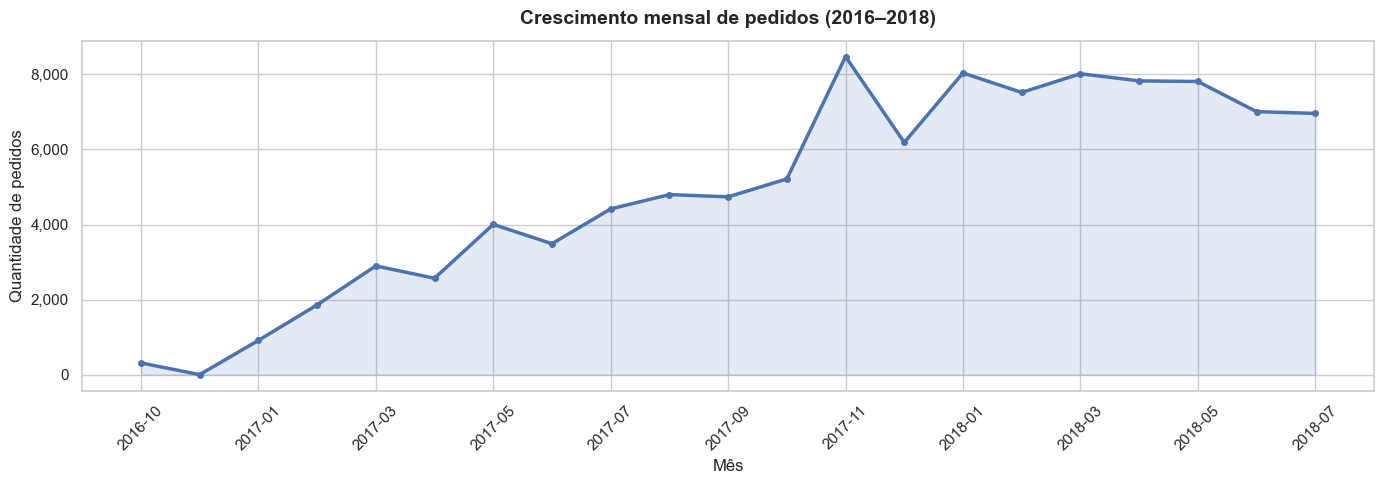

Mês com mais pedidos: 2017-11 com 8,474 pedidos
Crescimento total: de 313 para 6,960 pedidos/mês


In [7]:
# Gráfico 5 — Crescimento mensal de pedidos
df['mes'] = df['order_purchase_timestamp'].dt.to_period('M')
crescimento = df.groupby('mes')['order_id'].count().reset_index()
crescimento['mes_str'] = crescimento['mes'].astype(str)

# Remove meses incompletos nas pontas
crescimento = crescimento.iloc[1:-1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(crescimento['mes_str'], crescimento['order_id'], 
        color='#4C72B0', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(crescimento['mes_str'], crescimento['order_id'], 
                alpha=0.15, color='#4C72B0')
ax.set_title('Crescimento mensal de pedidos (2016–2018)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Mês')
ax.set_ylabel('Quantidade de pedidos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)
plt.xticks(crescimento['mes_str'][::2])

plt.tight_layout()
plt.savefig('../outputs/05_crescimento_mensal.png', dpi=150)
plt.show()

pico = crescimento.loc[crescimento['order_id'].idxmax()]
print(f"Mês com mais pedidos: {pico['mes_str']} com {pico['order_id']:,} pedidos")
print(f"Crescimento total: de {crescimento['order_id'].iloc[0]:,} para {crescimento['order_id'].iloc[-1]:,} pedidos/mês")